In [1]:
import torch 
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import os


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
class backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),        
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),        
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 64, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),        
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),        
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2)        
        )
    
    def forward(self, x):
        return self.features(x)
                 

In [4]:
class head(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),        # 14 → 7
            nn.Flatten(),
            nn.Linear(1024 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, 7 * 7 * 50)
        )
    
    def forward(self, x):
        return self.features(x)

In [5]:
class YOLO(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = backbone()
        self.head = head()
    
    def forward(self, x):
        x = self.backbone(x)
        
        x = self.head(x)
        x = x.view(-1, 7, 7, 50)
        return x

In [6]:
def iou(box1, box2):
    # Get coordinates of intersection
    x1 = torch.max(box1[..., 0] - box1[..., 2]/2, box2[..., 0] - box2[..., 2]/2)
    y1 = torch.max(box1[..., 1] - box1[..., 3]/2, box2[..., 1] - box2[..., 3]/2)
    x2 = torch.min(box1[..., 0] + box1[..., 2]/2, box2[..., 0] + box2[..., 2]/2)
    y2 = torch.min(box1[..., 1] + box1[..., 3]/2, box2[..., 1] + box2[..., 3]/2)

    # Intersection area
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    # Union area
    box1_area = box1[..., 2] * box1[..., 3]
    box2_area = box2[..., 2] * box2[..., 3]
    union = box1_area + box2_area - intersection

    return intersection / (union + 1e-6)
class YOLOLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss(reduction='sum')
        self.lambda_coord = 5
        self.lambda_noobj = 0.5

    def forward(self, predictions, targets):
        pred_box1 = predictions[..., 0:4]
        pred_box2 = predictions[..., 5:9]
        target_box = targets[..., 0:4]
        pred_conf1 = predictions[..., 4:5]
        pred_conf2 = predictions[..., 9:10]
        obj = targets[..., 4:5]
        noobj = 1 - obj

        iou_box1 = iou(pred_box1, target_box)
        iou_box2 = iou(pred_box2, target_box)
        best_box = (iou_box2 > iou_box1).float().unsqueeze(-1)
        pred_box = (1 - best_box) * pred_box1 + best_box * pred_box2

        coord_loss = self.mse(
            obj * pred_box[..., 0:2],
            obj * target_box[..., 0:2]
        )
        size_loss = self.mse(
            obj * torch.sign(pred_box[..., 2:4]) * torch.sqrt(torch.abs(pred_box[..., 2:4]) + 1e-6),
            obj * torch.sqrt(target_box[..., 2:4] + 1e-6)
        )

        pred_conf = (1 - best_box) * pred_conf1 + best_box * pred_conf2
        conf_loss_obj = self.mse(obj * pred_conf, obj * targets[..., 4:5])
        conf_loss_noobj = self.mse(noobj * pred_conf1, noobj * targets[..., 4:5]) + \
                          self.mse(noobj * pred_conf2, noobj * targets[..., 4:5])

        class_loss = self.mse(
            obj * predictions[..., 10:],
            obj * targets[..., 10:]
        )

        total_loss = (self.lambda_coord * (coord_loss + size_loss)
                    + conf_loss_obj
                    + self.lambda_noobj * conf_loss_noobj
                    + class_loss)

        return total_loss

In [7]:
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def encode_target(annotation, image_size=448, grid_size=7):
    target = torch.zeros(grid_size, grid_size, 50)
    
    for obj in annotation['annotation']['object']:
        # Get class
        class_name = obj['name']
        class_idx = VOC_CLASSES.index(class_name)
        
        # Get box coordinates normalized to 0-1
        xmin = float(obj['bndbox']['xmin']) / image_size
        ymin = float(obj['bndbox']['ymin']) / image_size
        xmax = float(obj['bndbox']['xmax']) / image_size
        ymax = float(obj['bndbox']['ymax']) / image_size
        
        # Box center, width, height
        x_center = (xmin + xmax) / 2
        y_center = (ymin + ymax) / 2
        width = xmax - xmin
        height = ymax - ymin
        
        # Which grid cell
        col = min(int(x_center * grid_size), grid_size - 1)
        row = min(int(y_center * grid_size), grid_size - 1)
        
        # Coordinates relative to cell
        x_cell = x_center * grid_size - col
        y_cell = y_center * grid_size - row
        
        # Fill target tensor
        if target[row, col, 4] == 0:  # if cell not already taken
            target[row, col, 0:5] = torch.tensor([x_cell, y_cell, width, height, 1])
            target[row, col, 10 + class_idx] = 1
    
    return target

class VOCDataset(Dataset):
    def __init__(self, root, image_set='train', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = datasets.VOCDetection(
            root=root,
            year='2012',
            image_set=image_set,
            download=True
        )
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, annotation = self.dataset[idx]
        image = image.resize((448, 448))
        if self.transform:
            image = self.transform(image)
        target = encode_target(annotation)
        return image, target
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Encode target
        target = encode_target(annotation)
        
        return image, target
    

In [8]:
transform = transforms.ToTensor()

train_dataset = VOCDataset(root='data', image_set='train', transform=transform)
val_dataset = VOCDataset(root='data', image_set='val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

100%|██████████| 2.00G/2.00G [00:56<00:00, 35.2MB/s]


In [9]:
model = YOLO()
model = nn.DataParallel(model)
model = model.to(device)
loss_fn = YOLOLoss()

In [10]:
model = YOLO()
model = nn.DataParallel(model)
model = model.to(device)
loss_fn = YOLOLoss()
optim = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs= 100
totaloss= 0
for epoch in range(num_epochs):
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)  
        optim.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, targets)
        totaloss += loss
        loss.backward()
        optim.step()
    print(f"Epoch {epoch+1} Loss: {totaloss.item()}")
    totaloss = 0

Epoch 1 Loss: 118929.3828125
Epoch 2 Loss: 50767.3203125
Epoch 3 Loss: 45483.47265625
Epoch 4 Loss: 44376.22265625
Epoch 5 Loss: 44814.57421875
Epoch 6 Loss: 43222.515625
Epoch 7 Loss: 43471.890625
Epoch 8 Loss: 42631.4140625
Epoch 9 Loss: 41769.3125
Epoch 10 Loss: 47155.74609375
Epoch 11 Loss: 40980.1484375
Epoch 12 Loss: 39594.55078125
Epoch 13 Loss: 39622.92578125
Epoch 14 Loss: 38428.953125
Epoch 15 Loss: 37854.4921875
Epoch 16 Loss: 39311.2265625
Epoch 17 Loss: 36531.28515625
Epoch 18 Loss: 34961.85546875
Epoch 19 Loss: 40157.98828125
Epoch 20 Loss: 37300.26953125
Epoch 21 Loss: 31714.955078125
Epoch 22 Loss: 36424.9453125
Epoch 23 Loss: 29702.85546875
Epoch 24 Loss: 26570.330078125
Epoch 25 Loss: 24319.4140625
Epoch 26 Loss: 22510.265625
Epoch 27 Loss: 21123.482421875
Epoch 28 Loss: 19540.71484375
Epoch 29 Loss: 17880.87109375
Epoch 30 Loss: 17260.103515625
Epoch 31 Loss: 15882.6455078125
Epoch 32 Loss: 14337.8662109375
Epoch 33 Loss: 12950.572265625
Epoch 34 Loss: 12695.06542968

In [11]:
model.eval()

DataParallel(
  (module): YOLO(
    (backbone): backbone(
      (features): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): LeakyReLU(negative_slope=0.1)
        (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): LeakyReLU(negative_slope=0.1)
        (11): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
        (12): BatchNorm2

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def cellboxes_to_boxes(out, S=7):
    # Convert the [Batch, 7, 7, 50] tensor into a list of bounding boxes
    batch_size = out.shape[0]
    out = out.to("cpu")
    
    # Extract the two potential boxes per cell and the classes
    box1 = out[..., 0:5]
    box2 = out[..., 5:10]
    classes = out[..., 10:]
    
    # Pick the box with higher confidence score
    best_box = (box2[..., 4:5] > box1[..., 4:5]).float()
    final_box = (1 - best_box) * box1 + best_box * box2
    
    # Get the class index with highest probability
    _, best_class = torch.max(classes, dim=-1)
    
    all_bboxes = []
    for b in range(batch_size):
        bboxes = []
        for r in range(S):
            for c in range(S):
                # Convert cell-relative coordinates to 0-1 image-relative
                x = (final_box[b, r, c, 0] + c) / S
                y = (final_box[b, r, c, 1] + r) / S
                w = final_box[b, r, c, 2]
                h = final_box[b, r, c, 3]
                conf = final_box[b, r, c, 4]
                
                if conf > 0.1: # Small threshold to catch everything initially
                    bboxes.append([best_class[b, r, c].item(), conf.item(), x, y, w, h])
        all_bboxes.append(bboxes)
    return all_bboxes

def nms(bboxes, iou_threshold=0.45, threshold=0.4):
    # Standard Non-Maximum Suppression to remove overlapping boxes
    bboxes = [box for box in bboxes if box[1] > threshold]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)
        bboxes = [
            box for box in bboxes
            if box[0] != chosen_box[0] or iou(torch.tensor(chosen_box[2:]), torch.tensor(box[2:])) < iou_threshold
        ]
        bboxes_after_nms.append(chosen_box)
    return bboxes_after_nms

In [13]:
# 1. Grab one batch
images, _ = next(iter(val_loader))
images = images.to(device)

# 2. Run through model
model.eval()
with torch.no_grad():
    predictions = model(images)

# 3. Process the first image in the batch
all_batch_boxes = cellboxes_to_boxes(predictions)
final_boxes = nms(all_batch_boxes[0], iou_threshold=0.45, threshold=0.3) # Adjust threshold if needed

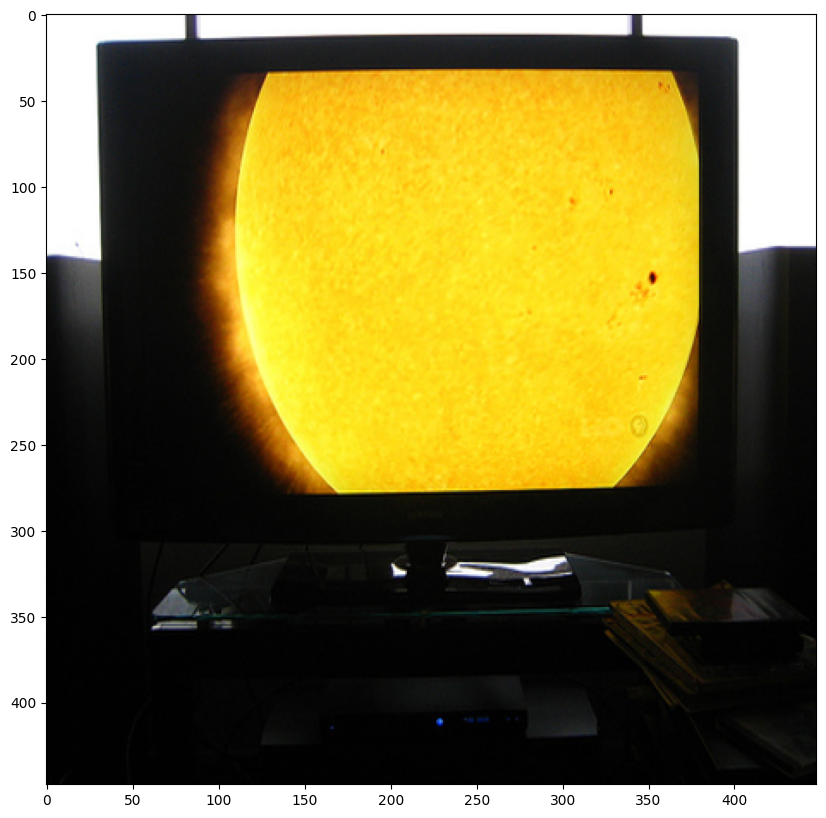

In [14]:
img = images[0].permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(img)

for box in final_boxes:
    class_idx, conf, x, y, w, h = box
    
    # Convert normalized (0-1) to pixel (0-448)
    # x,y are centers, we calculate top-left corner for matplotlib
    x_pixel = (x - w/2) * 448
    y_pixel = (y - h/2) * 448
    
    rect = patches.Rectangle(
        (x_pixel, y_pixel), w * 448, h * 448, 
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)
    plt.text(x_pixel, y_pixel, f"{VOC_CLASSES[int(class_idx)]} {conf:.2f}", 
             color='white', backgroundcolor='lime', fontsize=12)

plt.show()

In [15]:
def get_evaluation_bboxes(loader, model, iou_threshold, threshold, device="cuda"):
    model.eval()
    all_pred_boxes = []
    all_true_boxes = []
    train_idx = 0

    for x, labels in loader:
        x = x.to(device)
        with torch.no_grad():
            predictions = model(x)

        batch_size = x.shape[0]
        bboxes = cellboxes_to_boxes(predictions)
        true_bboxes = cellboxes_to_boxes(labels)

        for idx in range(batch_size):
            nms_boxes = nms(bboxes[idx], iou_threshold=iou_threshold, threshold=threshold)

            for nms_box in nms_boxes:
                all_pred_boxes.append([train_idx] + nms_box)

            for box in true_bboxes[idx]:
                if box[1] > threshold: # Only count objects that actually exist
                    all_true_boxes.append([train_idx] + box)

            train_idx += 1
    return all_pred_boxes, all_true_boxes

# Define a simple mAP function (simplified version of the standard)
def mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, num_classes=20):
    # pred_boxes format: [[train_idx, class_id, conf, x, y, w, h], ...]
    average_precisions = []
    epsilon = 1e-6

    for c in range(num_classes):
        detections = [d for d in pred_boxes if d[1] == c]
        ground_truths = [gt for gt in true_boxes if gt[1] == c]

        if len(ground_truths) == 0:
            continue

        detections.sort(key=lambda x: x[2], reverse=True)
        TP = torch.zeros((len(detections)))
        FP = torch.zeros((len(detections)))
        total_true_bboxes = len(ground_truths)

        for det_idx, detection in enumerate(detections):
            best_iou = 0
            for gt_idx, gt in enumerate(ground_truths):
                if gt[0] == detection[0]: # Same image
                    iou_val = iou(torch.tensor(detection[3:]), torch.tensor(gt[3:]))
                    if iou_val > best_iou:
                        best_iou = iou_val
            
            if best_iou > iou_threshold:
                TP[det_idx] = 1
            else:
                FP[det_idx] = 1

        TP_cumsum = torch.cumsum(TP, dim=0)
        FP_cumsum = torch.cumsum(FP, dim=0)
        recalls = TP_cumsum / (total_true_bboxes + epsilon)
        precisions = TP_cumsum / (TP_cumsum + FP_cumsum + epsilon)
        
        # Add points for the curve
        precisions = torch.cat((torch.tensor([1]), precisions))
        recalls = torch.cat((torch.tensor([0]), recalls))
        average_precisions.append(torch.trapz(precisions, recalls))

    return sum(average_precisions) / len(average_precisions)

In [16]:
print("Computing mAP... this may take a minute...")
pred_boxes, true_boxes = get_evaluation_bboxes(
    val_loader, model, iou_threshold=0.5, threshold=0.1, device=device
)

mAP_score = mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5)
print(f"Final mAP@0.5: {mAP_score.item():.4f}")

Computing mAP... this may take a minute...
Final mAP@0.5: 0.0163


In [17]:
# Save the 'module' because you are using DataParallel
torch.save(model.module.state_dict(), 'yolo_v1_trained_success.pth')
print("Weights secured!")

Weights secured!
